In [35]:
'''Imports'''
import os
import numpy as np
from pathlib import Path
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image
import io

In [2]:
'''Set filenames'''
dataDirName = "biggerDomainData/"
dataNames = "df."
dataExt = ".csv"

In [3]:
'''Count number of rows in each file'''
# for i in range(10):
#     df = dataNames + str(i) + dataExt
#     print(df)

# Sort key 
# - https://stackoverflow.com/questions/7304117/split-filenames-with-python
# - https://stackoverflow.com/questions/33159106/sort-filenames-in-directory-in-ascending-order
def extract_number(file_path):
    # For an example input of "df.10.csv" ...
    # .stem - takes off extension "df.10"
    # .split('.')[1] - splits into two elements "df" and "10" surrounding the ".", then selects the second element "10"
    return int(file_path.stem.split('.')[1])
dfNames = sorted(Path(dataDirName).glob('*.csv'), key=extract_number)
# test = dfNames[1]
# test3 = test.name

# Get number of data files
N = len(dfNames)

# Get data file names in a separate list
dfNamesList = [file.name for file in dfNames]
# print(dataDirName + dfNamesList[1])

# Get number of rows for each file - https://stackoverflow.com/questions/16108526/how-to-obtain-the-total-numbers-of-rows-from-a-csv-file-in-python
#   to make sure they're all the same length
rows = []
cols = []
for i in range(N):
    rows.append(pd.read_csv(dataDirName + dfNamesList[i]).shape[0])
    cols.append(pd.read_csv(dataDirName + dfNamesList[i]).shape[1])
# cols.append(5)

# Check that all of them are the same number of rows
avgRows = np.mean(rows)
avgCols = np.mean(cols)
if avgRows != rows[0] or avgCols != cols[0]:
    print("          Some files have inconsistent dimensions.  \n\
          The average numer of rows is %d, and the first file has %d rows. \n\
          The average numer of columns is %d, and the first file has %d columns." % (avgRows, rows[0], avgCols, cols[0]))
    raise
else:
    M = rows[0]

In [4]:
'''testing block - ignore'''
# Set desired column names
# desData = ["overpressure", "U:0", "U:1", "U:2", "Points:0", "timeOfArrival"]
# test = pd.read_csv(dataDirName + dfNamesList[0])
# test2 = pd.read_csv(dataDirName + dfNamesList[0], usecols = desData)
# test3 = test2[desData[0]]
# aaa = test.columns(desData)
# overpressures = [data for i in range(N)]
# [data.columns=["overpressure"] in range(N)]
# [file.name for file in dfNames]

'testing block - ignore'

In [10]:
'''Gather all csv data into a variable for easy plotting'''
# Set times
dt = 0.001
times = dt + np.arange(0,N) * dt

# Set desired column names
desData = ["overpressure", "U:0", "U:1", "U:2", "Points:0", "Points:1", "timeOfArrival"]

# Initialize arrays
overpressure = np.zeros((M,N))
u0 = np.zeros((M,N))
u1 = np.zeros((M,N))
u2 = np.zeros((M,N))
x = np.zeros((M,N))
y = np.zeros((M,N))
timeOfArrival = np.zeros((M,N))

# Get data
for i in range(N):
    data = pd.read_csv(dataDirName + dfNamesList[i], usecols = desData)
    # test = data[desData]
    overpressure[:, i], u0[:, i], u1[:, i], u2[:, i], x[:, i], y[:, i], timeOfArrival[:, i] = data[desData].values.T

r = np.hypot(x[:, 0], y[:, 0])

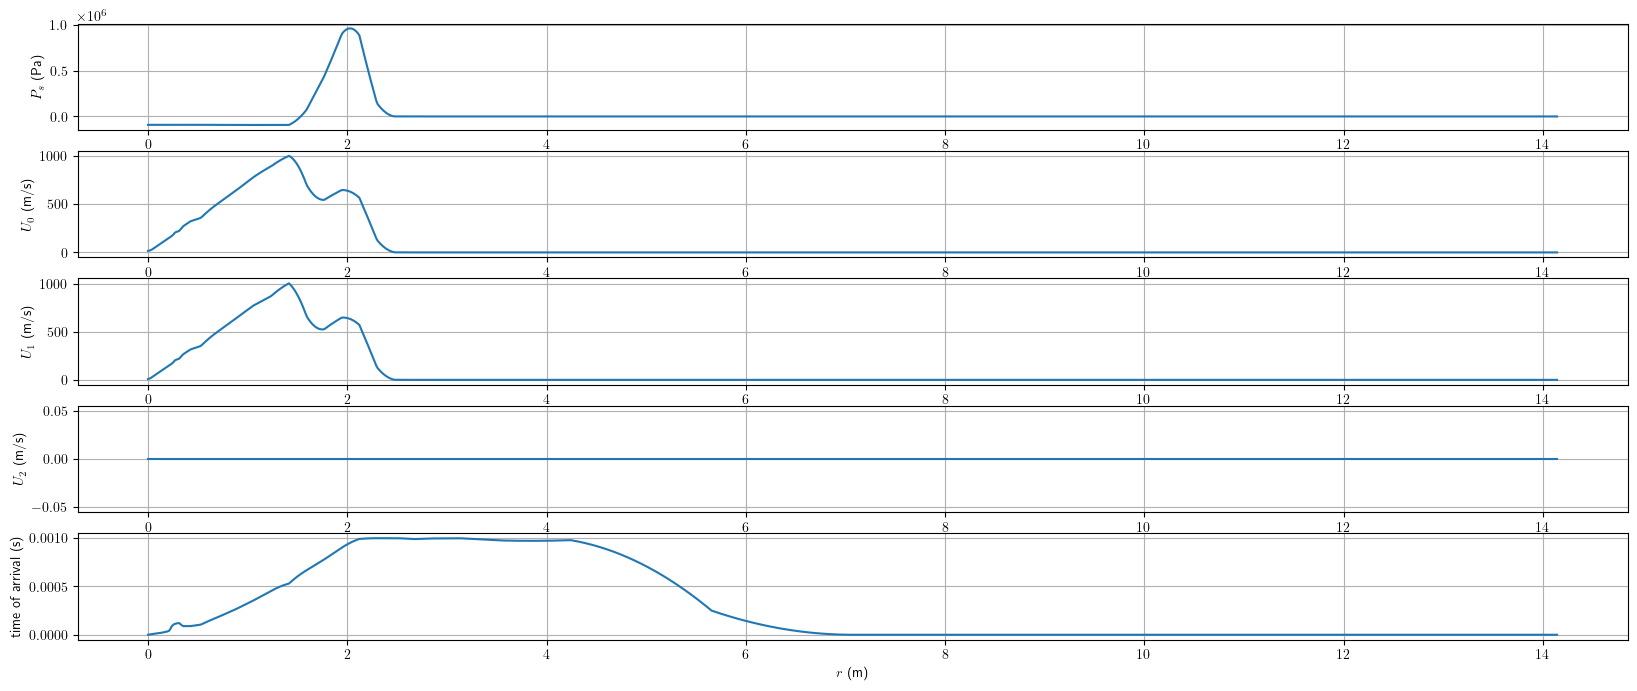

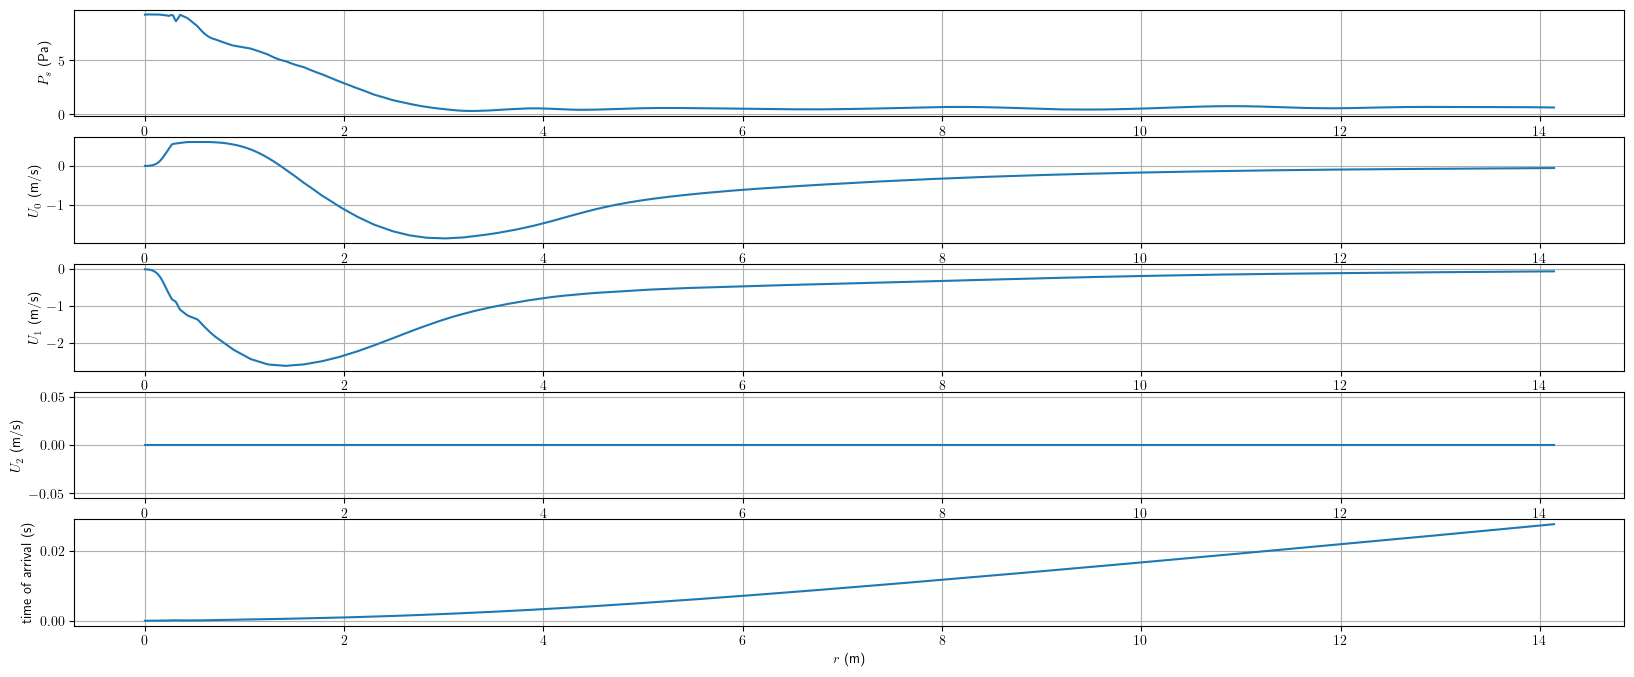

In [14]:
'''Plot first and last timesteps'''
# Make a plot
idx = 0
fig, ax = plt.subplots(nrows=5,ncols=1,figsize=(20,8))

# Overpressure
ax[0].plot(r,overpressure[:,idx])
ax[0].set_ylabel(r'$P_{s}$ (Pa)')
ax[0].grid(True)

# U0 - xdot?
ax[1].plot(r,u0[:,idx])
ax[1].set_ylabel(r'$U_{0}$ (m/s)')
ax[1].grid(True)

# U1 - ydot?
ax[2].plot(r,u1[:,idx])
ax[2].set_ylabel(r'$U_{1}$ (m/s)')
ax[2].grid(True)

# U2 - zdot?
ax[3].plot(r,u2[:,idx])
ax[3].set_ylabel(r'$U_{2}$ (m/s)')
ax[3].grid(True)

# time of arrival
ax[4].plot(r,timeOfArrival[:,idx])
ax[4].set_ylabel(r'time of arrival (s)')
ax[4].set_xlabel(r'$r$ (m)')
ax[4].grid(True)

# Make a plot
idx = N-1
fig, ax2 = plt.subplots(nrows=5,ncols=1,figsize=(20,8))

# Overpressure
ax2[0].plot(r,overpressure[:,idx])
ax2[0].set_ylabel(r'$P_{s}$ (Pa)')
ax2[0].grid(True)

# U0 - xdot?
ax2[1].plot(r,u0[:,idx])
ax2[1].set_ylabel(r'$U_{0}$ (m/s)')
ax2[1].grid(True)

# U1 - ydot?
ax2[2].plot(r,u1[:,idx])
ax2[2].set_ylabel(r'$U_{1}$ (m/s)')
ax2[2].grid(True)

# U2 - zdot?
ax2[3].plot(r,u2[:,idx])
ax2[3].set_ylabel(r'$U_{2}$ (m/s)')
ax2[3].grid(True)

# time of arrival
ax2[4].plot(r,timeOfArrival[:,idx])
ax2[4].set_ylabel(r'time of arrival (s)')
ax2[4].set_xlabel(r'$r$ (m)')
ax2[4].grid(True)


In [39]:
'''Plot things'''
# Set latex options for plots
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,bm}'  # https://stackoverflow.com/questions/23824687/text-does-not-work-in-a-matplotlib-label
plt.rcParams['text.usetex'] = True

# Set temp plot directory name
tmpPltName = "tmpPlt"
tmpPltDir = "tmpPlts/"
os.makedirs(tmpPltDir, exist_ok=True)

# Make all of the plots, save them as pngs, and combine them into a gif
# Make a plot
fig, ax = plt.subplots(nrows=5,ncols=1,figsize=(20,8))
for idx in range(N):
    # Make a plot
    fig, ax = plt.subplots(nrows=5,ncols=1,figsize=(20,8))

    # Overpressure
    ax[0].plot(r,overpressure[:,idx])
    ax[0].set_ylabel(r'$P_{s}$ (Pa)')
    ax[0].grid(True)

    # U0 - xdot?
    ax[1].plot(r,u0[:,idx])
    ax[1].set_ylabel(r'$U_{0}$ (m/s)')
    ax[1].grid(True)

    # U1 - ydot?
    ax[2].plot(r,u1[:,idx])
    ax[2].set_ylabel(r'$U_{1}$ (m/s)')
    ax[2].grid(True)

    # U2 - zdot?
    ax[3].plot(r,u2[:,idx])
    ax[3].set_ylabel(r'$U_{2}$ (m/s)')
    ax[3].grid(True)

    # time of arrival
    ax[4].plot(r,timeOfArrival[:,idx])
    ax[4].set_ylabel(r'time of arrival (s)')
    ax[4].set_xlabel(r'$r$ (m)')
    ax[4].grid(True)

    # Save plot in directory
    fig.savefig(tmpPltDir + tmpPltName + str(idx), format='png')


: 

In [33]:
imgs[0].save('paramsVsRadius.gif', save_all=True, append_images=imgs[0], loop=0)

TypeError: 'PngImageFile' object is not iterable